---
title: "See Which Training Rows Drive a TabPFN Prediction"
description: "Interpret TabPFN predictions as weighted votes from training rows with the ManyClassDecoder readout"
cookbookTags:
  - interpretability
  - classification
authors:
  - name: Eliott Kalfon
    linkedin: https://www.linkedin.com/in/eliott-kalfon/
---

*Follow one prediction back to the training rows that voted for it.*

The final predicted label of TabPFN is an attention-weighted average over context labels. This means that each classification prediction is a weighted vote over actual context labels. In this cookbook, you will see how to see exactly which rows TabPFN attended to to generate a prediction. We will use the heart-statlog dataset as example.

> This explains the model's computation. It does not show that a training row caused heart disease, and it is not medical advice.

## Setup

*Install the local TabPFN model, the decoder helpers, and UMAP for clear 2D views.*

The decoder readout needs the local model because it reads an internal attention layer. The hosted API does not expose this layer.

In [1]:
!pip install -q --upgrade "tabpfn>=8.4.0" tabpfn-extensions umap-learn

In [2]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

from tabpfn_extensions import TabPFNClassifier
from tabpfn_extensions.interpretability import (
    class_vote,
    get_decoder_readout,
    plot_decoder_readout,
)

warnings.filterwarnings("ignore", message="n_jobs value 1 overridden")
plt.style.use("seaborn-v0_8-whitegrid")
CLASS_NAMES = ["no disease", "heart disease"]
CLASS_COLORS = ["#2A78D6", "#EB6834"]

If the model asks for access, add `TABPFN_TOKEN` to Colab secrets. This cell leaves existing local authentication unchanged.

In [3]:
try:
    from google.colab import userdata

    token = userdata.get("TABPFN_TOKEN")
    if token:
        os.environ["TABPFN_TOKEN"] = token
except Exception:
    pass

## Load Heart Statlog

*Use short names so the rows stay easy to scan.*

Heart Statlog has 270 rows, 13 patient features, and two classes. We keep 200 rows for training and 70 for testing.

In [4]:
RENAME = {
    "age": "Age",
    "sex": "Sex",
    "chest": "Chest pain",
    "resting_blood_pressure": "Resting BP",
    "serum_cholestoral": "Cholesterol",
    "fasting_blood_sugar": "High fasting sugar",
    "resting_electrocardiographic_results": "Resting ECG",
    "maximum_heart_rate_achieved": "Max heart rate",
    "exercise_induced_angina": "Exercise angina",
    "oldpeak": "ST depression",
    "slope": "ST slope",
    "number_of_major_vessels": "Blocked vessels",
    "thal": "Thallium scan",
}
CATEGORICAL = [
    "Sex", "Chest pain", "High fasting sugar", "Resting ECG",
    "Exercise angina", "ST slope", "Thallium scan",
]

In [5]:
heart = fetch_openml("heart-statlog", version=1, as_frame=True)
X = heart.data.astype(float).rename(columns=RENAME)
y = (heart.target == "present").astype(int)
cat_idx = [X.columns.get_loc(name) for name in CATEGORICAL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=200, test_size=70, random_state=42, stratify=y
)

counts = pd.DataFrame({
    "train": y_train.value_counts().sort_index(),
    "test": y_test.value_counts().sort_index(),
}).rename(index=dict(enumerate(CLASS_NAMES)))
counts

,train,test
class,,
no disease,111,39
heart disease,89,31


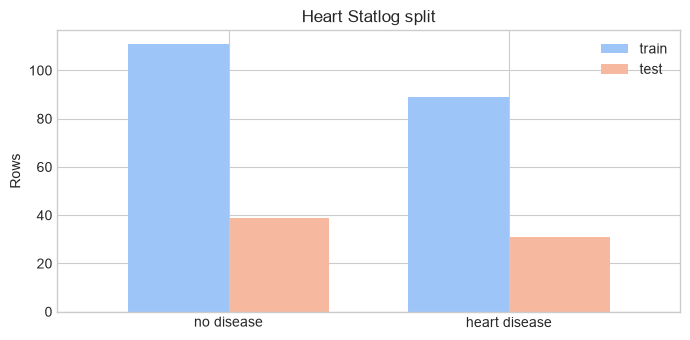

In [6]:
ax = counts.plot.bar(
    color=["#9EC5F8", "#F6B99F"], figsize=(7, 3.5), rot=0, width=0.72
)
ax.set(title="Heart Statlog split", xlabel="", ylabel="Rows")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## Fit TabPFN

In [7]:
X_train_array = X_train.to_numpy()
X_test_array = X_test.to_numpy()
y_train_array = y_train.to_numpy()
y_test_array = y_test.to_numpy()

clf = TabPFNClassifier(
    categorical_features_indices=cat_idx,
    softmax_temperature=1.0,
    balance_probabilities=False,
    random_state=42,
)
clf.fit(X_train_array, y_train_array)
probabilities = clf.predict_proba(X_test_array)

## Read the Decoder Votes

*Recover one weight for every test-row/training-row pair.*

For a given test row, all training-row weights are non-negative and sum to one. Adding the weights within each class gives that class's vote.

In [8]:
weights, train_idx = get_decoder_readout(clf, X_test_array)
X_train_aligned = X_train_array[train_idx]
y_train_aligned = y_train_array[train_idx]
votes, classes = class_vote(weights, y_train_aligned)

## One Prediction as a Table

*Start with the most uncertain test row.*

This row has a heart-disease vote closest to 50%. The table ranks the training rows by decoder weight. Its first rows had the strongest vote.

In [9]:
focus_query = int(np.argmin(np.abs(votes[:, 1] - 0.5)))
focus_summary = pd.DataFrame({
    "true class": [CLASS_NAMES[y_test_array[focus_query]]],
    "decoder prediction": [CLASS_NAMES[int(np.argmax(votes[focus_query]))]],
    "no-disease vote": [votes[focus_query, 0]],
    "heart-disease vote": [votes[focus_query, 1]],
})
focus_summary.style.format({
    "no-disease vote": "{:.1%}",
    "heart-disease vote": "{:.1%}",
})

,true class,decoder prediction,no-disease vote,heart-disease vote
0,heart disease,heart disease,45.4%,54.6%


In [10]:
readout_table = X_train.iloc[train_idx].copy().reset_index()
readout_table = readout_table.rename(columns={readout_table.columns[0]: "source row"})
readout_table.insert(1, "class", [CLASS_NAMES[label] for label in y_train_aligned])
readout_table.insert(2, "decoder weight", weights[focus_query])
readout_table = readout_table.sort_values("decoder weight", ascending=False)

readout_table.head(10).style.format({"decoder weight": "{:.3%}"}).bar(
    subset=["decoder weight"], color="#8CB9F1"
)

,source row,class,decoder weight,Age,Sex,Chest pain,Resting BP,Cholesterol,High fasting sugar,Resting ECG,Max heart rate,Exercise angina,ST depression,ST slope,Blocked vessels,Thallium scan
68,31,no disease,2.076%,66.000000,1.000000,4.000000,160.000000,228.000000,0.000000,2.000000,138.000000,0.000000,2.300000,1.000000,0.000000,6.000000
135,96,no disease,1.994%,66.000000,1.000000,4.000000,120.000000,302.000000,0.000000,2.000000,151.000000,0.000000,0.400000,2.000000,0.000000,3.000000
49,248,heart disease,1.709%,60.000000,1.000000,3.000000,140.000000,185.000000,0.000000,2.000000,155.000000,0.000000,3.000000,2.000000,0.000000,3.000000
85,10,no disease,1.671%,59.000000,1.000000,4.000000,135.000000,234.000000,0.000000,0.000000,161.000000,0.000000,0.500000,2.000000,0.000000,7.000000
23,76,no disease,1.595%,45.000000,1.000000,4.000000,104.000000,208.000000,0.000000,2.000000,148.000000,1.000000,3.000000,2.000000,0.000000,3.000000
56,11,no disease,1.515%,53.000000,1.000000,4.000000,142.000000,226.000000,0.000000,2.000000,111.000000,1.000000,0.000000,1.000000,0.000000,7.000000
178,210,heart disease,1.406%,59.000000,1.000000,1.000000,170.000000,288.000000,0.000000,2.000000,159.000000,0.000000,0.200000,2.000000,0.000000,7.000000
38,131,heart disease,1.397%,66.000000,1.000000,4.000000,112.000000,212.000000,0.000000,2.000000,132.000000,1.000000,0.100000,1.000000,1.000000,3.000000
32,5,no disease,1.356%,65.000000,1.000000,4.000000,120.000000,177.000000,0.000000,0.000000,140.000000,0.000000,0.400000,1.000000,0.000000,7.000000
69,18,no disease,1.335%,64.000000,1.000000,1.000000,110.000000,211.000000,0.000000,2.000000,144.000000,1.000000,1.800000,2.000000,0.000000,3.000000


The first row has the largest single weight. The prediction still uses all 200 training rows, not just the ten shown here.

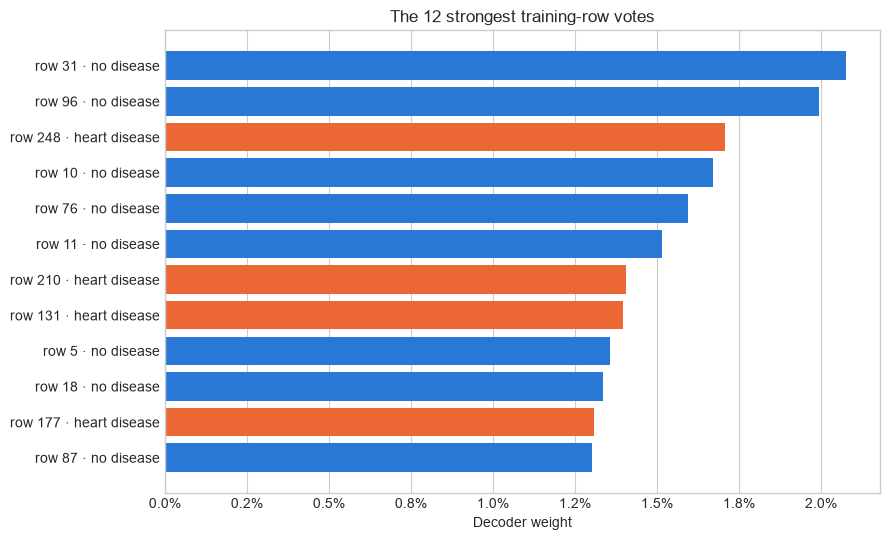

In [11]:
top = readout_table.head(12).sort_values("decoder weight")
colors = top["class"].map(dict(zip(CLASS_NAMES, CLASS_COLORS)))
labels = top.apply(lambda row: f"row {row['source row']} · {row['class']}", axis=1)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(labels, top["decoder weight"], color=colors)
ax.set(
    title="The 12 strongest training-row votes",
    xlabel="Decoder weight",
    ylabel="",
)
ax.xaxis.set_major_formatter(lambda x, _: f"{x:.1%}")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

## One Prediction in Raw Feature Space

*Place the test row and its strongest voters on a 2D map of the original columns.*

The star is the test row. A line joins it to each of its 20 strongest training rows. Thicker lines mean larger weights. Blue and orange mark the training class.

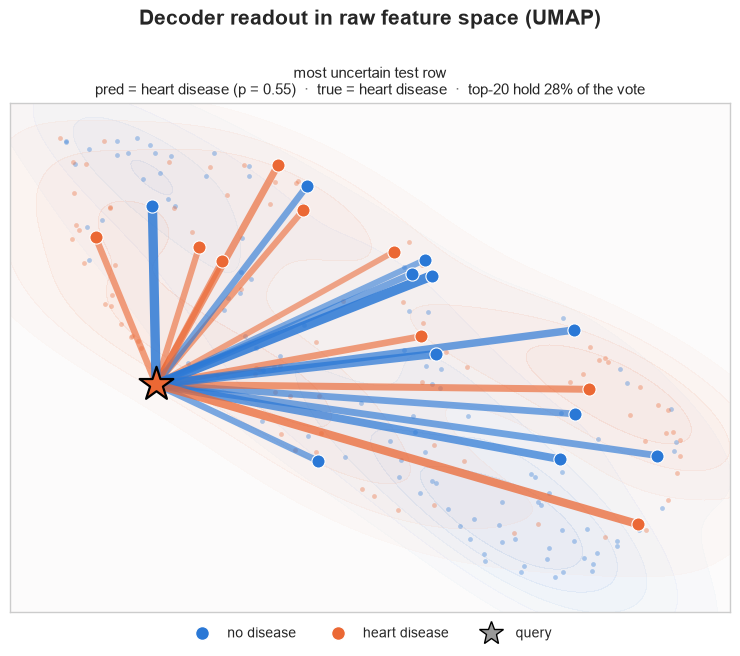

In [12]:
fig = plot_decoder_readout(
    weights,
    [focus_query],
    X_train_aligned,
    X_test_array,
    y_train_aligned,
    CLASS_NAMES,
    y_test=y_test_array,
    colors=CLASS_COLORS,
    query_titles=["most uncertain test row"],
    title="Decoder readout in raw feature space",
)
plt.show()

## The Same Prediction in Embedding Space

TabPFN turns each row into a learned embedding before the decoder acts. This view projects those embeddings to 2D. It often places the strongest voters closer to the star and separates the two classes more clearly.

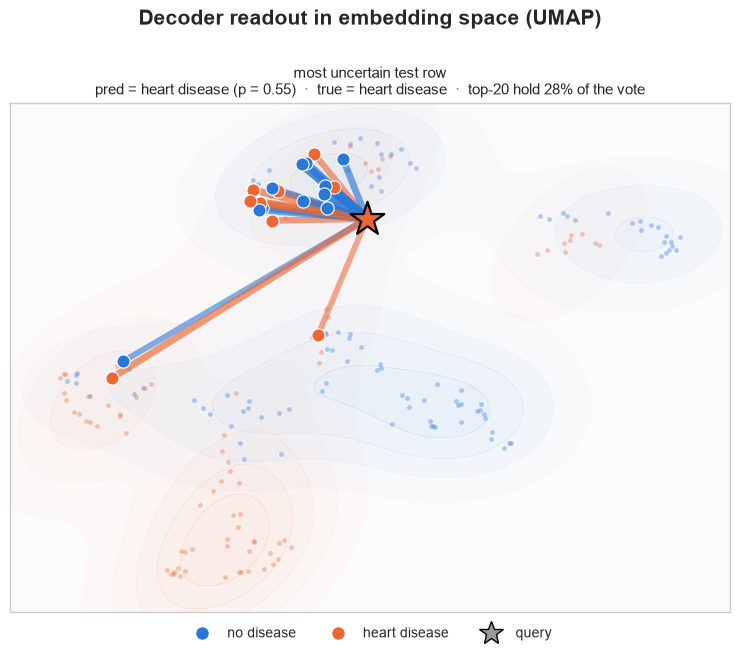

In [13]:
train_embeddings = clf.get_embeddings(X_test_array, data_source="train").mean(axis=0)[train_idx]
test_embeddings = clf.get_embeddings(X_test_array, data_source="test").mean(axis=0)

fig = plot_decoder_readout(
    weights,
    [focus_query],
    X_train_aligned,
    X_test_array,
    y_train_aligned,
    CLASS_NAMES,
    y_test=y_test_array,
    embeddings=(train_embeddings, test_embeddings),
    colors=CLASS_COLORS,
    query_titles=["most uncertain test row"],
    title="Decoder readout in embedding space",
)
plt.show()

The raw and embedding plots show exactly the same decoder weights. Only the map changes. UMAP compresses many dimensions into two, so distances in either picture are useful summaries, not exact model distances.

## Four Predictions Together

*Compare confident and uncertain votes in one view.*

We choose the lowest heart-disease predicted probability, the two observations nearest the 50% predicted probability from either side, and the largest predicted probability.

In [14]:
def pick_queries(p_heart):
    order = np.argsort(p_heart)
    split = np.clip(np.searchsorted(p_heart[order], 0.5), 1, len(order) - 1)
    return [order[0], order[split - 1], order[split], order[-1]]

queries = pick_queries(votes[:, 1])
query_titles = [
    "confident no disease",
    "uncertain · leans no disease",
    "uncertain · leans heart disease",
    "confident heart disease",
]

pd.DataFrame({
    "test position": queries,
    "case": query_titles,
    "true class": [CLASS_NAMES[y_test_array[q]] for q in queries],
    "heart-disease vote": votes[queries, 1],
}).style.format({"heart-disease vote": "{:.1%}"})

,test position,case,true class,heart-disease vote
0,52,confident no disease,no disease,1.2%
1,64,uncertain · leans no disease,heart disease,45.1%
2,29,uncertain · leans heart disease,heart disease,54.6%
3,34,confident heart disease,heart disease,99.8%


### Combined raw-feature view

The original feature map can mix rows from the two classes. Strong decoder links may cross large parts of this 2D view.

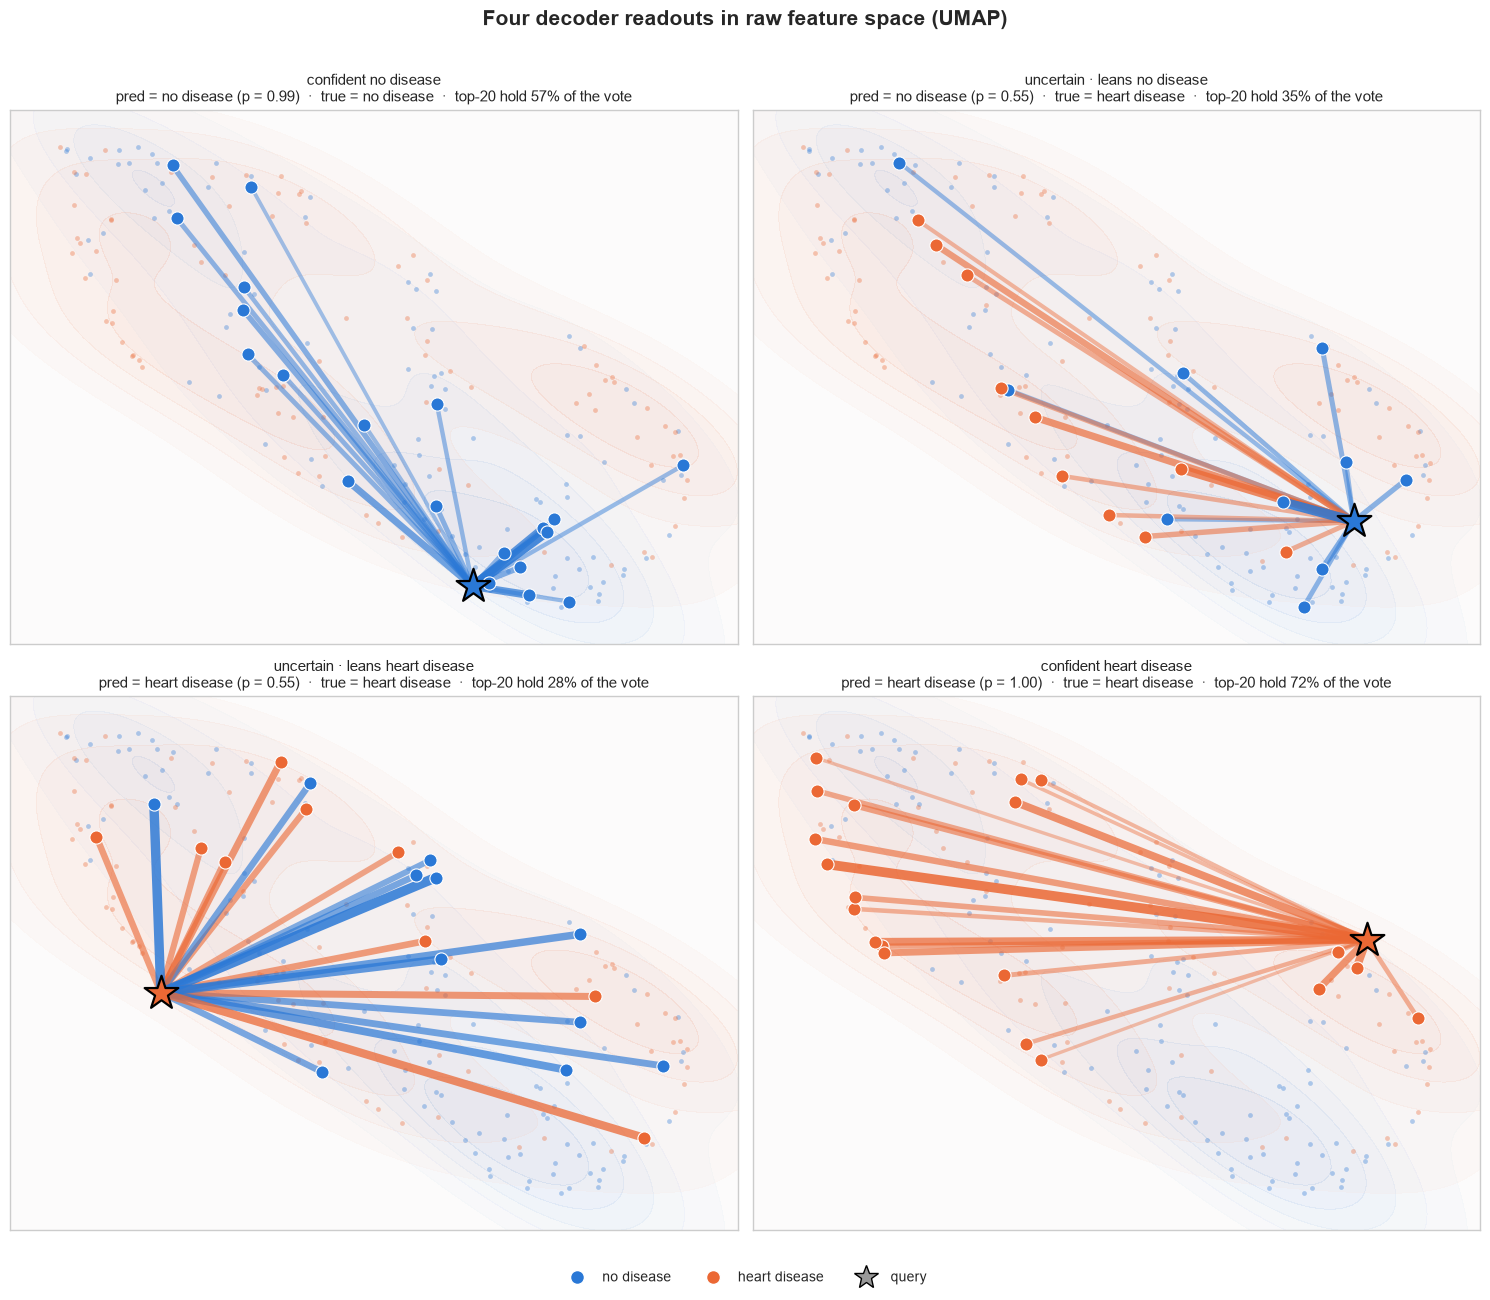

In [15]:
fig = plot_decoder_readout(
    weights,
    queries,
    X_train_aligned,
    X_test_array,
    y_train_aligned,
    CLASS_NAMES,
    y_test=y_test_array,
    colors=CLASS_COLORS,
    query_titles=query_titles,
    title="Four decoder readouts in raw feature space",
)
plt.show()

### Combined embedding view

In the learned map, the same links tend to stay within clearer class regions. This is the space that best reveals what the decoder keys on.

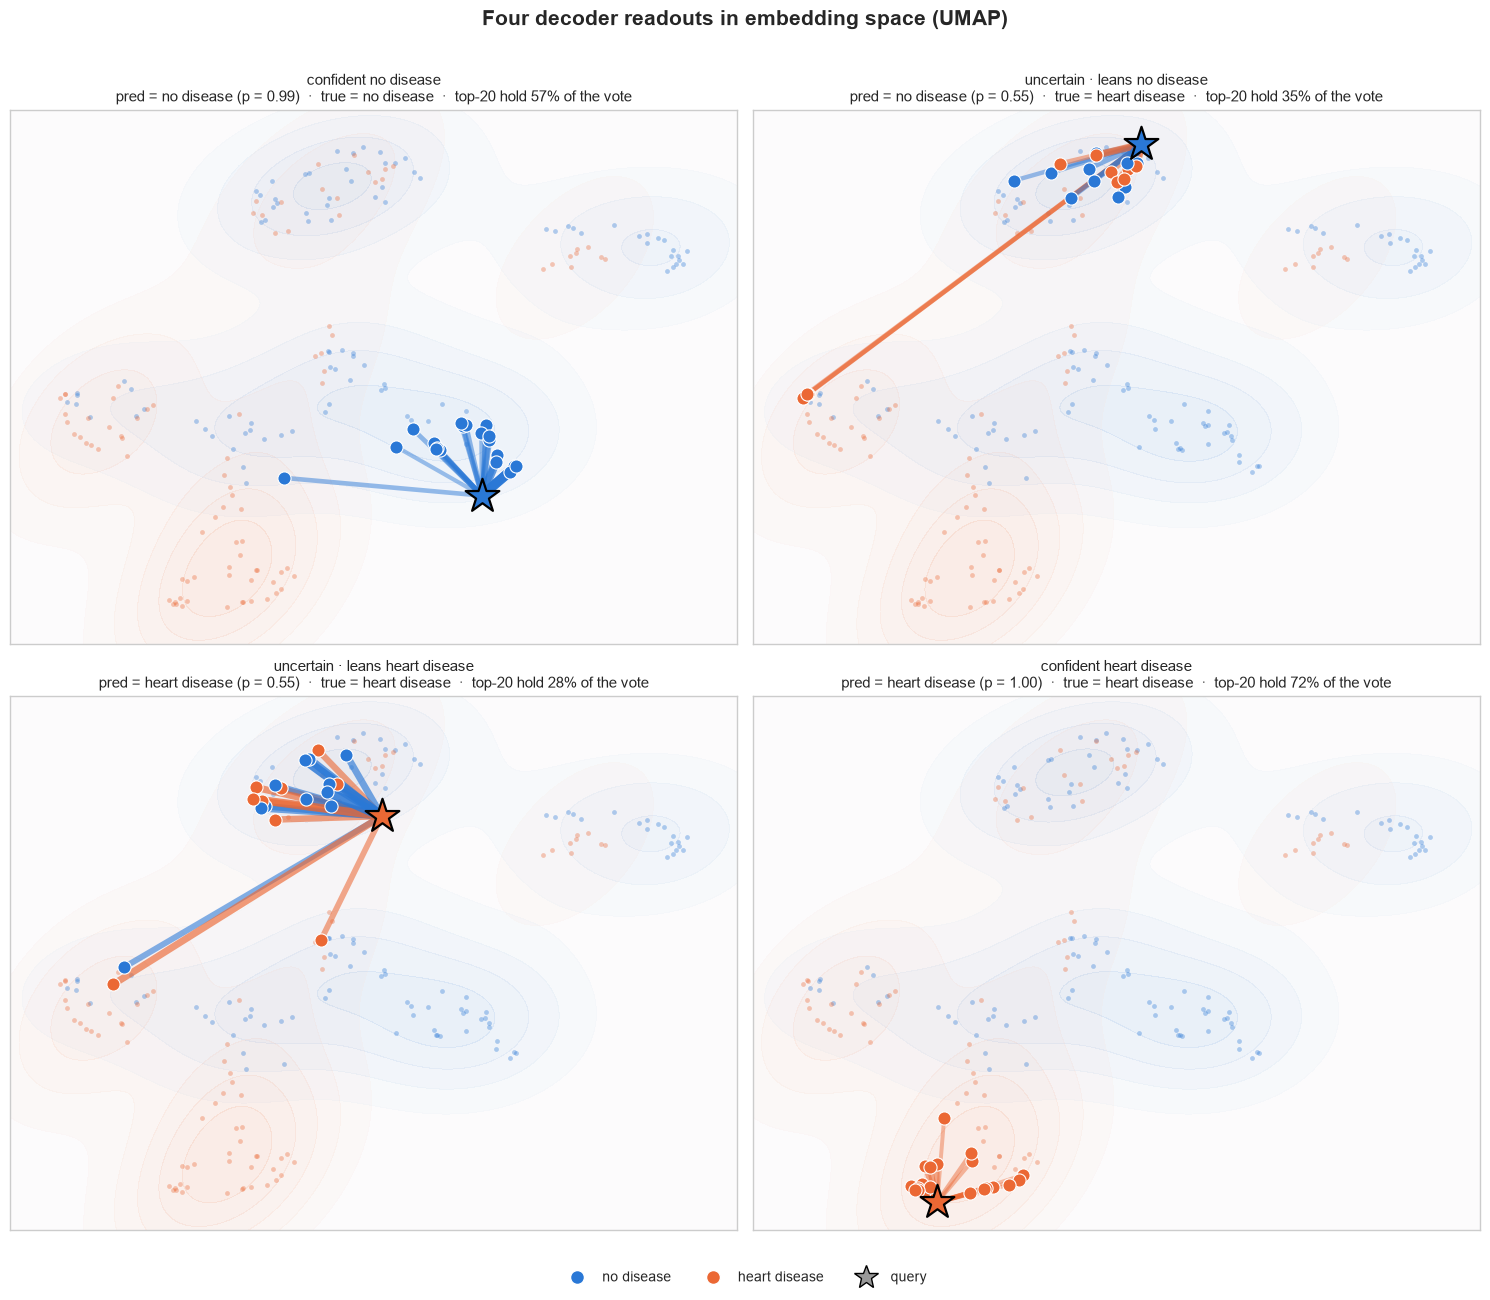

In [16]:
fig = plot_decoder_readout(
    weights,
    queries,
    X_train_aligned,
    X_test_array,
    y_train_aligned,
    CLASS_NAMES,
    y_test=y_test_array,
    embeddings=(train_embeddings, test_embeddings),
    colors=CLASS_COLORS,
    query_titles=query_titles,
    title="Four decoder readouts in embedding space",
)
plt.show()

## What to Keep

- A decoder weight says how much one training row voted for one test row.
- Summing weights by class gives the class vote.
- The table is exact; the 2D maps are visual summaries.
- Raw space shows observations in the raw feature space. Embedding space is closer to the model's own view.

The decoder readout is most useful for finding influential examples, checking whether a prediction rests on one row or many, and spotting surprising voters worth a closer look.

Further reading: [decoder readout example](https://github.com/PriorLabs/tabpfn-extensions/blob/main/examples/interpretability/decoder_readout_example.py) and [interpretability helpers](https://github.com/PriorLabs/tabpfn-extensions/tree/main/src/tabpfn_extensions/interpretability).